In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# Rechargement et preparation des donnees
df = pd.read_csv("../data/creditcard.csv")

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df = df.drop(columns=["Amount", "Time"])

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Entrainement du modele
print("Entrainement du Random Forest en cours...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)
print("Modele entraine avec succes !")

Entrainement du Random Forest en cours...
Modele entraine avec succes !


AUC-ROC : 0.9688

=== Rapport de classification ===
              precision    recall  f1-score   support

    Legitime       1.00      1.00      1.00     56864
      Fraude       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



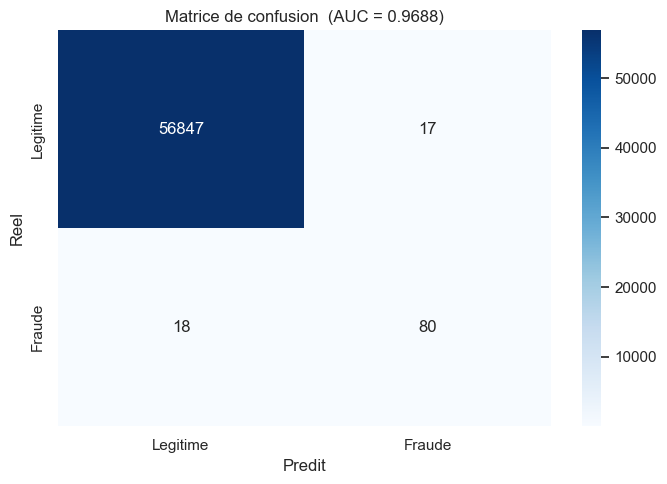

In [2]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC : {auc:.4f}")

# Rapport de classification
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=["Legitime", "Fraude"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitime", "Fraude"],
            yticklabels=["Legitime", "Fraude"])
ax.set_title(f"Matrice de confusion  (AUC = {auc:.4f})")
ax.set_ylabel("Reel")
ax.set_xlabel("Predit")
plt.tight_layout()
plt.savefig("../outputs/06_matrice_confusion.png", dpi=150)
plt.show()